Plot results for Thermodynamic Neuron:<br>
- virtual temperature: NOT
- effect of varying epsilon_z
- steady state temp
- AND gate behaviour
- OR gate behaviour


In [1]:
import numpy as np
import scipy.integrate as si
import matplotlib.pyplot as plt
import pandas as pd

- **beta_v**<br>
Input: input inverse temperature<br>
Output: virtual temperature for gate (see function name) given input
- **gibbs**  <br>
Input: qubit Hamiltonian $H$, inverse temperature of heat bath $β$ <br>
Output: steady state of qubit - full set of probabilities of ground and excited state.
- **beta_inf** (1d = 1 input, 2d = 2 inputs)<br>
Input: energy gaps for 1 and z qubit, input inverse temperature<br>
Output: steady state output temperature of bath $z$

In [2]:
def beta_v_NOT(beta_1, epsilon_v, epsilon_1):

    beta_v = (epsilon_0*beta_0/epsilon_v) - (epsilon_1*beta_1/epsilon_v)
    return beta_v

def beta_v_OR(beta_1,beta_2):
    beta_v = alpha*(1/epsilon_z)*(2*(beta_1+beta_2)-1)
    return beta_v

def beta_v_AND(beta_1,beta_2):
    beta_v = alpha*(1/epsilon_z)*((2/3)*(beta_1+beta_2) - 1)
    return beta_v

def gibbs(energy,beta):

    g = 1/(np.exp(energy*beta)+1)
    return g

def beta_inf_1d(beta_1, epsilon_z, epsilon_1):

    delta = gibbs(epsilon_z, beta_min)-gibbs(epsilon_z,beta_max)
    populations = (delta*gibbs(epsilon_z,beta_v_NOT(beta_1,epsilon_z,epsilon_1)))+gibbs(epsilon_z,beta_max)
    beta_inf = (1/epsilon_z)*np.log((1/populations)-1)
    return beta_inf

def beta_inf_2d(beta_1,beta_2, gate):
    if gate == 'OR':
      beta_v = beta_v_OR(beta_1,beta_2)
    elif gate == 'AND':
      beta_v = beta_v_AND(beta_1,beta_2)

    kappa = gibbs(epsilon_z,beta_min) - gibbs(epsilon_z, beta_max)
    beta_inf = (1/epsilon_z)*np.log(-1+1/(kappa*gibbs(epsilon_z, beta_v)+gibbs(epsilon_z,beta_max)))
    return beta_inf


Plot virtual temperature for **NOT** gate <br>
$\beta_v = \frac{\epsilon_0}{\epsilon_v}\beta_0 - \frac{\epsilon_1}{\epsilon_v}\beta_1$<br>
- $\epsilon_0, \epsilon_1, \epsilon_v=\epsilon_0 - \epsilon_1$ - energy gaps of $0$, $1$ and virtual qubit.
- $\beta_0, \beta_1$ - inverse temperature of bath coupled to $0$ and $1$ qubit. We vary $beta_1$ and consider how it affects the virtual inverse temperature.



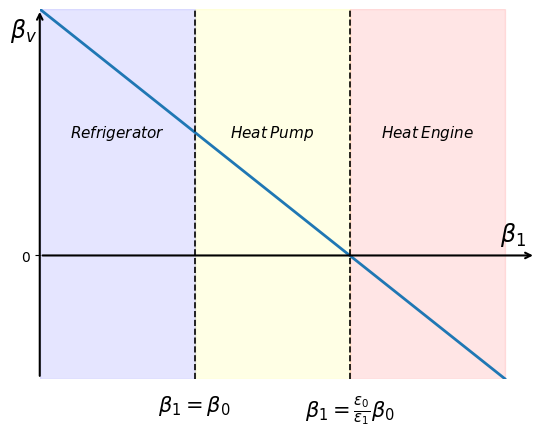

In [3]:
# Constants
epsilon_0 = 10
epsilon_1 = 5
epsilon_v = epsilon_0 - epsilon_1

beta_0 = 10

x = np.linspace(0, 30, 100)
y = beta_v_NOT(x, epsilon_v, epsilon_1)

fig, ax = plt.subplots()

ax.set_xlim(0, 32)
ymin, ymax = y.min(), y.max()
ax.set_ylim(ymin, ymax)

# --- Shaded regions ---
ax.axvspan(0, 10, color='blue', alpha=0.1)
ax.axvspan(10, 20, color='yellow', alpha=0.1)
ax.axvspan(20, 30, color='red', alpha=0.1)

# --- Plot ---
ax.plot(x, y, linewidth=2)


ax.axvline(x=10, color='black', linestyle='--', linewidth=1.2)
ax.axvline(x=20, color='black', linestyle='--', linewidth=1.2)

# --- Remove default axes ---
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.set_xticks([])
ax.set_yticks([0])

# --- Draw arrow axes ---
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.annotate('', xy=(xmax, 0), xytext=(xmin, 0),
            arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

ax.annotate('', xy=(0, ymax), xytext=(0, ymin),
            arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

# --- Axis labels at arrow tips ---
dx = (xmax - xmin) * 0.02
dy = (ymax - ymin) * 0.02

ax.text(xmax - dx, 0 + dy, r'$\beta_1$',
        ha='right', va='bottom', fontsize=17)

ax.text(0 - 3*dx, ymax - dy, r'$\beta_v$',
        ha='left', va='top', fontsize=17)

# --- Boundary labels ---
offset = (ymax - ymin) * 0.04
ax.text(10, ymin - offset, r'$\beta_1 = \beta_0$',
        ha='center', va='top', fontsize=15)

ax.text(20, ymin - offset,
        r'$\beta_1 = \frac{\epsilon_0}{\epsilon_1}\beta_0$',
        ha='center', va='top', fontsize=15)

# --- Region labels ---
ax.text(5, 10, r'$Refrigerator$', ha='center', va='center', fontsize=11)
ax.text(15, 10, r'$Heat\:Pump$', ha='center', va='center', fontsize=11)
ax.text(25, 10, r'$Heat \: Engine$', ha='center', va='center', fontsize=11)

plt.show()


Plot steady state output temperature for **NOT** gate <br>
- In blue, $\beta_z^\infty= \frac{1}{\epsilon_z}\text{log}[\frac{1}{\Delta g(\epsilon_z,\beta_v)+g(\epsilon_z,\beta_{max})} - 1]$
- In red, $f(x) = \frac{1}{1+e^{x}}$ with $x = (\epsilon_z+\epsilon_1)(\beta_1 - \beta_0)$. The ideal sigmoid function. The steady state behaviour tends to this function as $\epsilon_z$ is decreased.


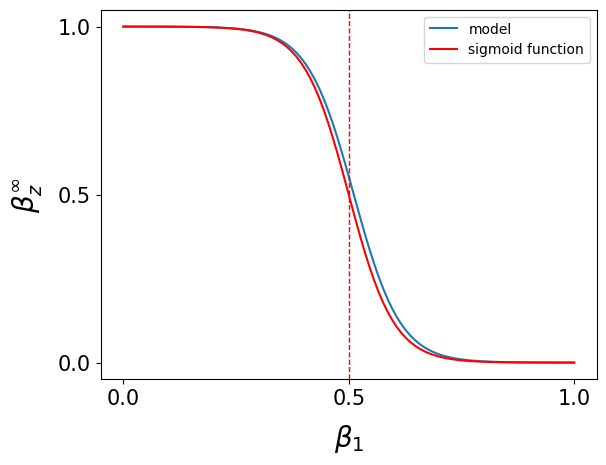

In [4]:
# Constants
epsilon_0 = 20
epsilon_1 = 19.5
epsilon_v = epsilon_0 - epsilon_1
epsilon_z = epsilon_v

beta_0 = 0.5
beta_min = 0
beta_max = 1

x = np.linspace(0, 1, 100)
y_inf = beta_inf_1d(x, epsilon_z, epsilon_1)
x_new = -1*(epsilon_1 + epsilon_z)*(beta_0-x)
y = 1/(1+np.exp(x_new))

plt.plot(x, y_inf, label = 'model')
plt.plot(x,y,color='red', label = 'sigmoid function')
plt.xlabel(r'$\beta_1$', labelpad=10, fontsize=20)
plt.ylabel(r'$\beta_z^\infty$', labelpad=10, fontsize=20)
plt.yticks([0.0, 0.5, 1.0])
plt.xticks([0.0,0.5,1.0])
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1)
plt.legend()


plt.show()


Plot of steady state **NOT** behaviour for different values of $\epsilon_1$.

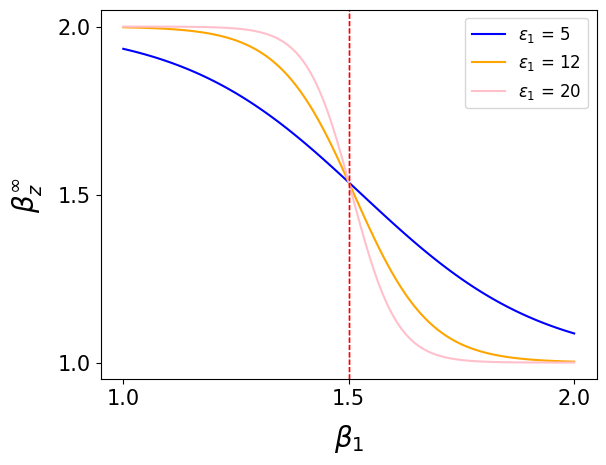

In [5]:
beta_0 = 1.5 # beta_1 is variable
beta_min = 1
beta_max = 2

def plot_graph(epsilon_1, color):
    # epsilon_v = epsilon_0 - epsilon_1

    epsilon_v = 0.1
    epsilon_0 = epsilon_v + epsilon_1

    epsilon_z = epsilon_v
    x = np.linspace(1, 2, 100)
    y_inf = beta_inf_1d(x,epsilon_z, epsilon_1)

    plt.plot(x, y_inf, color = color)
    plt.xlabel(r'$\beta_1$', labelpad=10)
    plt.ylabel(r'$\beta_z^\infty$', labelpad=10)


epsilon_0 = 5.1
plot_graph(5, 'blue')
epsilon_0 = 12.1
plot_graph(12, 'orange')
epsilon_0 = 20.1
plot_graph(20, 'pink')
# Add dotted vertical lines (zones)
plt.axvline(x=1.5, color='red', linestyle='--', linewidth=1)


plt.xlabel(r'$\beta_1$', labelpad=10, fontsize=20)
plt.ylabel(r'$\beta_z^\infty$', labelpad=10, fontsize=20)
plt.yticks([1.0, 1.5, 2.0])
plt.xticks([1.0,1.5,2.0])
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.axvline(x=1.5, color='red', linestyle='--', linewidth=1)
plt.legend([r'$\epsilon_1$ = 5',r'$\epsilon_1$ = 12',r'$\epsilon_1$ = 20' ], fontsize=12)
plt.show()

Plot probability of excitation for signal qubit depending on input to NOT gate

Plot of thermodynamic **AND** gate behaviour.

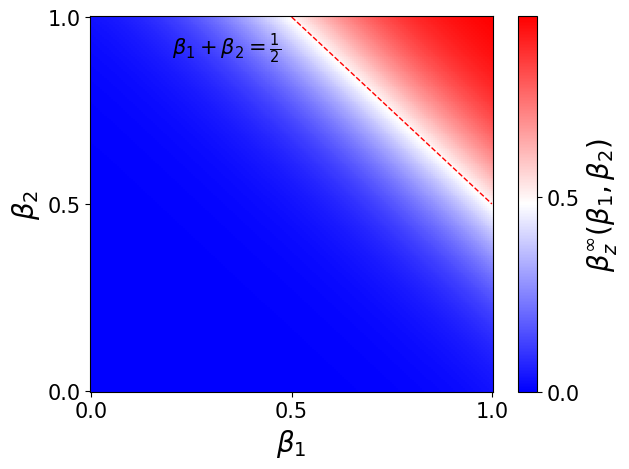

In [8]:
# Constants
epsilon_z = 0.1
alpha = 10
epsilon = alpha*[(epsilon_z+4), 2, 2]
beta_0 = 1/(epsilon_z+4)
beta_min = 0
beta_max = 1

# Create grid of beta_1 and beta_2 values
beta_1 = np.linspace(0, 1, 200)  # adjust range as needed
beta_2 = np.linspace(0, 1, 200)
B1, B2 = np.meshgrid(beta_1, beta_2)

# Evaluate beta_v over the grid
beta_steady = beta_inf_2d(B1,B2, 'AND')

# Plot color map
plt.pcolormesh(B1, B2, beta_steady, cmap='bwr',shading = 'auto')

cbar = plt.colorbar(label=r'$\beta^\infty_z(\beta_1, \beta_2)$')
cbar.ax.tick_params(labelsize=15)  # make tick numbers big
cbar.set_ticks([0.0, 0.5])
cbar.set_label(r'$\beta^\infty_z(\beta_1, \beta_2)$', fontsize=20)

x = np.linspace(0.5, 1, 200)
plt.plot(x, 1.5-x, color='red', linestyle='--', linewidth=1)

plt.text(0.2, 0.90, r'$\beta_1+\beta_2=\frac{1}{2}$', color = 'black', fontsize=15)
#plt.title(r'$\beta_z^\infty(\beta_1, \beta_2)$')
plt.xlabel(r'$\beta_1$', fontsize=20)
plt.ylabel(r'$\beta_2$', fontsize=20)
plt.yticks([0.0, 0.5, 1.0])
plt.xticks([0.0,0.5,1.0])
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.tight_layout()
plt.show()

Plot of thermodynamic **OR** gate.

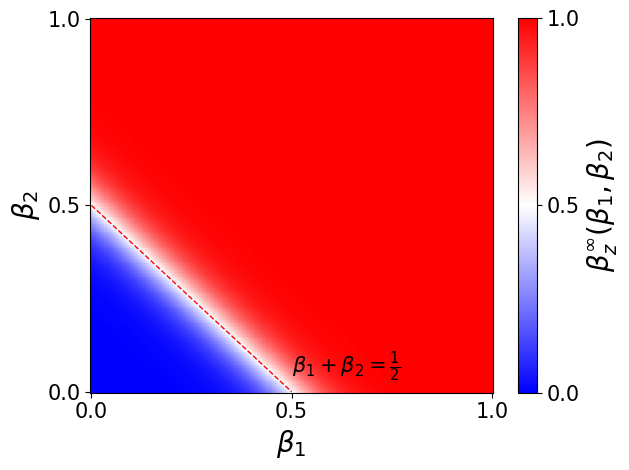

In [7]:
# Constants
epsilon_z = 0.1
alpha = 10
epsilon = alpha*[(epsilon_z+4), 2, 2]
beta_0 = 1/(epsilon_z+4)
beta_min = 0
beta_max = 1

# Create grid of beta_1 and beta_2 values
beta_1 = np.linspace(0, 1, 200)  # adjust range as needed
beta_2 = np.linspace(0, 1, 200)
B1, B2 = np.meshgrid(beta_1, beta_2)

# Evaluate beta_v over the grid
beta_steady = beta_inf_2d(B1,B2, 'OR')

# Plot color map
plt.pcolormesh(B1, B2, beta_steady, cmap='bwr',shading = 'auto')

cbar = plt.colorbar(label=r'$\beta^\infty_z(\beta_1, \beta_2)$')
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=15)  # make tick numbers big
cbar.set_label(r'$\beta^\infty_z(\beta_1, \beta_2)$', fontsize=20)

x = np.linspace(0, 0.5, 200)
plt.plot(x, 0.5-x, color='red', linestyle='--', linewidth=1)

plt.text(0.5, 0.05, r'$\beta_1+\beta_2=\frac{1}{2}$', color = 'black', fontsize=15)
#plt.title(r'$\beta_z^\infty(\beta_1, \beta_2)$')
plt.xlabel(r'$\beta_1$', fontsize=20)
plt.ylabel(r'$\beta_2$', fontsize=20)
plt.yticks([0.0, 0.5, 1.0])
plt.xticks([0.0,0.5,1.0])
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.tight_layout()
plt.show()

